In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import xgboost as xgb

In [4]:
df = pd.read_csv("adhd_data.csv")
df = df.drop_duplicates()

print("Shape:", df.shape)
print(df["Diagnosis_Class"].value_counts())
print(df.head())

Shape: (6500, 32)
Diagnosis_Class
3    2800
0    1600
2    1050
1    1050
Name: count, dtype: int64
   Age  Gender Educational_Level Family_History  Sleep_Hours  \
0    8       1           Primary             No            8   
1    9       2           Primary             No           11   
2    9       1           Primary             No            9   
3    5       2      Kindergarten            Yes            7   
4   13       1            Middle             No            3   

   Daily_Activity_Hours  Q1_1  Q1_2  Q1_3  Q1_4  ...  Q2_8  Q2_9  \
0                     7     0     0     0     1  ...     0     1   
1                     7     3     2     2     3  ...     2     3   
2                     5     3     2     3     3  ...     2     3   
3                    11     3     3     3     2  ...     0     0   
4                     0     3     2     3     3  ...     1     0   

   Diagnosis_Class  Daily_Phone_Usage_Hours  Daily_Walking_Running_Hours  \
0                0            

In [5]:
data = df.copy()

for col in data.select_dtypes(include="object").columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

X = data.drop(columns=["Diagnosis_Class"]).values
y = data["Diagnosis_Class"].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

print(X.shape)

(6500, 31)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4875, 31) Test: (1625, 31)


In [7]:
A_train = kneighbors_graph(X_train, n_neighbors=8, include_self=True)
edge_train = np.array(A_train.nonzero())

train_data = Data(
    x=torch.tensor(X_train, dtype=torch.float),
    edge_index=torch.tensor(edge_train, dtype=torch.long),
    y=torch.tensor(y_train, dtype=torch.long)
)

print(train_data)

Data(x=[4875, 31], edge_index=[2, 39000], y=[4875])


In [8]:
A_test = kneighbors_graph(X_test, n_neighbors=8, include_self=True)
edge_test = np.array(A_test.nonzero())

test_data = Data(
    x=torch.tensor(X_test, dtype=torch.float),
    edge_index=torch.tensor(edge_test, dtype=torch.long),
    y=torch.tensor(y_test, dtype=torch.long)
)

print(test_data)

Data(x=[1625, 31], edge_index=[2, 13000], y=[1625])


In [9]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden, heads=4, dropout=0.5)
        self.gat2 = GATConv(hidden * 4, out_channels, heads=1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = self.gat2(x, edge_index)
        return x

model = GAT(X.shape[1], 32, len(np.unique(y)))
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

In [10]:
losses = []

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    out = model(train_data)
    loss = F.cross_entropy(out, train_data.y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 25 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 1.3722448348999023
Epoch: 25 Loss: 0.005086373537778854
Epoch: 50 Loss: 0.0033902330324053764
Epoch: 75 Loss: 0.0032336669974029064
Epoch: 100 Loss: 0.004217152483761311
Epoch: 125 Loss: 0.0028447650838643312
Epoch: 150 Loss: 0.0020136029925197363
Epoch: 175 Loss: 0.0017573320074006915


In [11]:
model.eval()

train_emb = model(train_data).detach().numpy()
test_emb = model(test_data).detach().numpy()

print("Train Emb:", train_emb.shape)
print("Test Emb:", test_emb.shape)
print(train_emb[:5])

Train Emb: (4875, 4)
Test Emb: (1625, 4)
[[-7.223268   -2.2341695  -1.8366288   8.488269  ]
 [-6.9014006  -3.080294   -1.0479062   8.319839  ]
 [ 1.4013355   8.795638   -7.59847    -2.9146113 ]
 [ 1.707073    9.9549     -8.040321   -3.2859998 ]
 [ 0.84310865  9.263102   -7.86422    -2.375472  ]]


In [12]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="multi:softmax",
    num_class=len(np.unique(y))
)

xgb_model.fit(train_emb, y_train)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.85
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [13]:
y_pred = xgb_model.predict(test_emb)

acc = accuracy_score(y_test, y_pred)

print("GAT + XGBoost Accuracy:", acc)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

GAT + XGBoost Accuracy: 0.9993846153846154
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      1.00      1.00       263
           2       1.00      1.00      1.00       262
           3       1.00      1.00      1.00       700

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

[[400   0   0   0]
 [  1 262   0   0]
 [  0   0 262   0]
 [  0   0   0 700]]


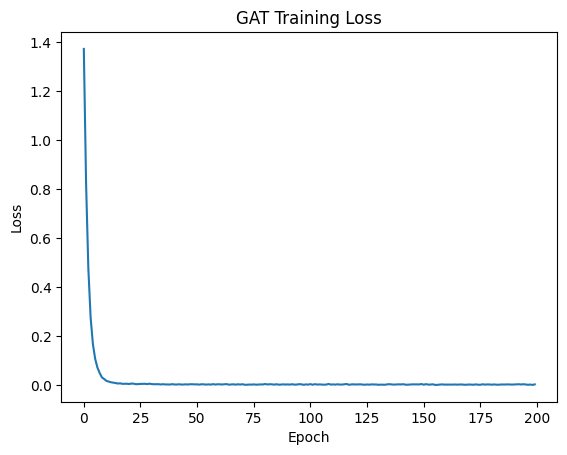

In [14]:
plt.figure()
plt.plot(losses)
plt.title("GAT Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

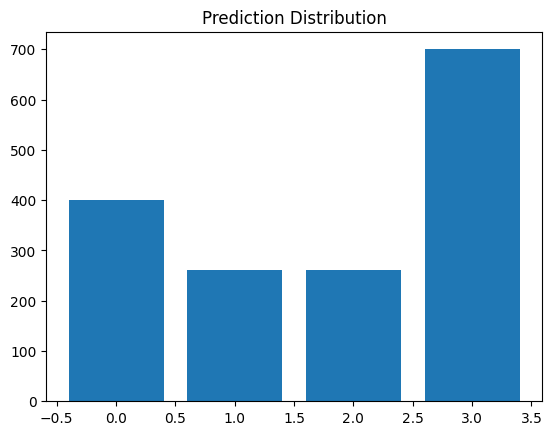

In [15]:
plt.figure()
u, c = np.unique(y_pred, return_counts=True)
plt.bar(u, c)
plt.title("Prediction Distribution")
plt.show()

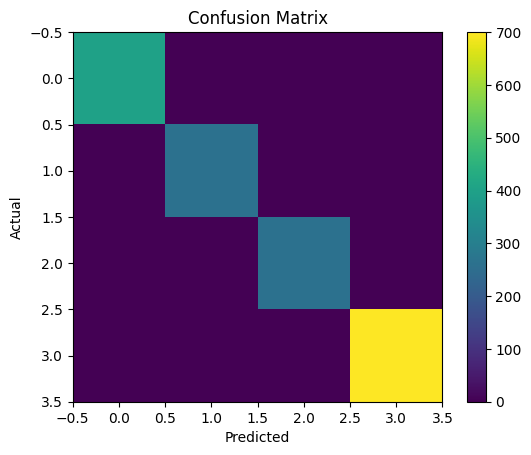

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()